This project follows to find the best possible suitor for the next world cup in 2038

In [139]:
import pandas as pd
import numpy as np
import requests
import io
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from adjustText import adjust_text

First data source: 2026_FIFA_World_Cup_squads from Wikipedia, using because it lists important data about the players such as: 

* official appearances a player has made for the national team
* for what club they play
* age
* name
* position

Scraped using this tutorial to make sure its actually legal to pull from wikipedia: [GeeksforGeeks](https://www.geeksforgeeks.org/python/web-scraping-from-wikipedia-using-python-a-complete-guide/) but using pandas instead of beautiful soup

In [140]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

wiki_url = "https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_squads"

wiki_html = requests.get(wiki_url, headers = headers)
wiki_df = pd.read_html(io.StringIO(wiki_html.text))

team_tables_df = []

for wiki_section in wiki_df:
    if 'Player' in wiki_section.columns:
        wiki_section = wiki_section.dropna(subset=['Player'])
        team_tables_df.append(wiki_section)

players_df = pd.concat(team_tables_df, ignore_index=True)

# cleanup player dataframe column names
players_df = players_df.drop(columns=["No."])
players_df = players_df.rename(columns = {"Date of birth (age)" : "Age", "Pos." : "Position", "Caps" : "Number of Appereances"})

# extract only the age of the player not the day they were born
players_df["Age"] = players_df["Age"].str.split()
players_df["Age"] = players_df["Age"].str[4]
players_df["Age"] = players_df["Age"].str.strip(')')

# take out the (captain) tag in the player name
players_df["Player"] = players_df["Player"].str.split('(')
players_df["Player"] = players_df["Player"].str[0]

# make sure all number columns are integers
players_df["Age"] = players_df["Age"].astype(int)
players_df["Number of Appereances"] = players_df["Number of Appereances"].astype(int)
players_df["Goals"] = players_df["Goals"].astype(int)

# put Player name as the first column
player_col = players_df.pop("Player")
players_df.insert(0, "Player", player_col)

players_df


,Player,Position,Age,Number of Appereances,Goals,Club
0,Matěj Kovář,GK,26,19,0,PSV Eindhoven
1,Jindřich Staněk,GK,30,14,0,Slavia Prague
2,Lukáš Horníček,GK,23,0,0,Braga
3,Vladimír Coufal,DF,33,61,2,TSG Hoffenheim
4,Tomáš Holeš,DF,33,39,2,Slavia Prague
...,...,...,...,...,...,...
1251,Azarias Londoño,MF,24,10,0,Universidad Católica
1252,José Fajardo,FW,32,65,17,Universidad Católica
1253,Ismael Díaz,FW,29,54,17,León
1254,Cecilio Waterman,FW,35,52,14,Universidad de Concepción


To fill in more information about our players we use an exisiting [Kaggle Dataset](https://www.kaggle.com/datasets/davidcariboo/player-scores?resource=download&select=clubs.csv). that pulls data from [Transfermarkt](https://www.transfermarkt.com/) . From the data set we extract the players.csv file. This will helps us include the following columns in our dataframe:
* country players were born in (previously very hard to do with wikipedia parsing)
* current market valuation in euros (most important number because it sets up what our regression tries to predict)
* peak market valuation in euros
* column that checks if the current player market value is at its maximum (the player is in his prime)

In [141]:

# prepare the new columns
players_df['Club League'] = None
players_df['Country'] = None
players_df['Current MV'] = None
players_df['Peak MV'] = None

kaggle_df = pd.read_csv('./players.csv')

player_name = ""
for row_index, player_name in players_df['Player'].items():
    if player_name in kaggle_df['name'].values:
        kaggle_row = kaggle_df[kaggle_df['name'] == player_name].iloc[0]
        players_df.at[row_index, 'Club League'] = kaggle_row['current_club_domestic_competition_id']
        players_df.at[row_index, 'Country'] = kaggle_row['country_of_citizenship']
        players_df.at[row_index, 'Current MV'] = kaggle_row['market_value_in_eur']
        players_df.at[row_index, 'Peak MV'] = kaggle_row['highest_market_value_in_eur']

# normalize country names to be the same name (for old countries that no longer exist)
players_df['Country'] = players_df['Country'].replace({'CSSR': 'Czech Republic'})
players_df['Country'] = players_df['Country'].replace({'Jugoslawien (SFR)': 'Croatia'})

players_df


,Player,Position,Age,Number of Appereances,Goals,Club,Club League,Country,Current MV,Peak MV
0,Matěj Kovář,GK,26,19,0,PSV Eindhoven,None,None,None,None
1,Jindřich Staněk,GK,30,14,0,Slavia Prague,None,None,None,None
2,Lukáš Horníček,GK,23,0,0,Braga,None,None,None,None
3,Vladimír Coufal,DF,33,61,2,TSG Hoffenheim,L1,Czech Republic,2700000.0,12000000.0
4,Tomáš Holeš,DF,33,39,2,Slavia Prague,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...
1251,Azarias Londoño,MF,24,10,0,Universidad Católica,NaN,Panama,1200000.0,1200000.0
1252,José Fajardo,FW,32,65,17,Universidad Católica,None,None,None,None
1253,Ismael Díaz,FW,29,54,17,León,MEX1,Panama,1800000.0,2000000.0
1254,Cecilio Waterman,FW,35,52,14,Universidad de Concepción,None,None,None,None


Check number of missing values before and after stripping them off. As we can see the wikipedia dataset had all values introduced and none missing while the same cannot be said about the dataset from kaggle.

In [142]:
print('Before dropping missing values:')
print(players_df.isna().sum())
print('')

# drop values wherever there are missing values for the players for: 'Country', 'Current MV', 'Peak MV'
players_df = players_df.dropna(subset=['Country', 'Current MV', 'Peak MV', 'Club League']).reset_index(drop=True)

print('After dropping missing values:')
print(players_df.isna().sum())

Before dropping missing values:
Player                     0
Position                   0
Age                        0
Number of Appereances      0
Goals                      0
Club                       0
Club League              403
Country                  276
Current MV               292
Peak MV                  292
dtype: int64

After dropping missing values:
Player                   0
Position                 0
Age                      0
Number of Appereances    0
Goals                    0
Club                     0
Club League              0
Country                  0
Current MV               0
Peak MV                  0
dtype: int64


Finish normalizing columns by adding proper categories to variables/columns. We use 4 main types of variables types: object, categroy, int64 and bool.

In [143]:
# make sure all number columns are integers
players_df["Current MV"] = players_df["Current MV"].astype(int)
players_df["Peak MV"] = players_df["Peak MV"].astype(int)

# fix column types to add the category type where needed
players_df['Position'] = players_df['Position'].astype('category')
players_df['Club'] = players_df['Club'].astype('category')
players_df['Club League'] = players_df['Club League'].astype('category')
players_df['Country'] = players_df['Country'].astype('category')

# based on the current valuation and peak valuation add a bool type column if they are in the peak of their career
players_df['Apex MV'] = (players_df['Current MV'] == players_df['Peak MV']).astype('bool')

print(players_df.dtypes)
print('')

players_df

Player                     object
Position                 category
Age                         int64
Number of Appereances       int64
Goals                       int64
Club                     category
Club League              category
Country                  category
Current MV                  int64
Peak MV                     int64
Apex MV                      bool
dtype: object



,Player,Position,Age,Number of Appereances,Goals,Club,Club League,Country,Current MV,Peak MV,Apex MV
0,Vladimír Coufal,DF,33,61,2,TSG Hoffenheim,L1,Czech Republic,2700000,12000000,False
1,David Zima,DF,25,24,1,Slavia Prague,TS1,Czech Republic,7000000,7500000,False
2,Jaroslav Zelený,DF,33,21,0,Sparta Prague,TS1,Czech Republic,600000,1500000,False
3,David Jurásek,DF,25,16,1,Slavia Prague,TS1,Czech Republic,5000000,8000000,False
4,Tomáš Souček,MF,31,89,17,West Ham United,GB1,Czech Republic,12000000,45000000,False
...,...,...,...,...,...,...,...,...,...,...,...
832,Yoel Bárcenas,MF,32,101,10,Mazatlán,MEX1,Panama,650000,1500000,False
833,Adalberto Carrasquilla,MF,27,73,3,UNAM,MEX1,Panama,4000000,4500000,False
834,José Luis Rodríguez,MF,27,67,8,Juárez,MEX1,Panama,2500000,2500000,True
835,Carlos Harvey,MF,26,25,2,Minnesota United FC,MLS1,Panama,600000,600000,True


Split dataset into a training and testing set. Snippet de cod luat din laborator. Reserve 75% of data for training and 25% for testing. Export created dataset into the train.csv and test.csv to help run the models later.

In [ ]:
target = players_df['Current MV']
features = players_df.drop(columns=['Current MV', 'Player'])

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.25, random_state=42)

test_data = pd.concat([X_test, y_test], axis=1)
train_data = pd.concat([X_train, y_train], axis=1)

test_data.to_csv('test.csv', index=False)
train_data.to_csv('train.csv', index=False)

print(f"Test set data dimension: {test_data.shape}")
print(f"Training set data dimension: {train_data.shape}")

Test set data dimension: (210, 10)
Training set data dimension: (627, 10)


Describe our data sets to help see the ranges of our data and the repeatedness of some certain values. Most interestingly to see and to confirm also that the most amount of players come from the Premier League which is regarded as the hardest football league and where MV skyrocket. It is important to know that we dont have to check or treat missing values as we made sure the overall dataset is clean. 

In [ ]:
print("X_train numerical statistics")
print(X_train.describe())

print('')

print("X_train categorical statistics")
print(X_train.describe(include=['category', 'bool']))

print('')

print("y_train target statistics")
print(y_train.describe())

X_train Numerical Statistics
              Age  Number of Appereances       Goals       Peak MV
count  627.000000             627.000000  627.000000  6.270000e+02
mean    26.846890              27.344498    3.325359  2.295869e+07
std      4.067188              26.045843    7.876607  2.888118e+07
min     18.000000               0.000000    0.000000  2.500000e+04
25%     24.000000               7.000000    0.000000  4.000000e+06
50%     27.000000              21.000000    1.000000  1.150000e+07
75%     29.000000              41.000000    3.000000  3.200000e+07
max     43.000000             152.000000   89.000000  2.000000e+08

X_train Categorical Statistics
       Position            Club Club League    Country Apex MV
count       627             627         627        627     627
unique        4             269          29         42       2
top          DF  Crystal Palace         GB1  Argentina   False
freq        212              11         112         37     369

y_train Target Stati

Plot graphs that help visualise the data we are working with. Graphs included are:
* Distribution of Current Market Value by Tiers
* Distribution of Players by Position
* Players at their Peak Valuation
* 

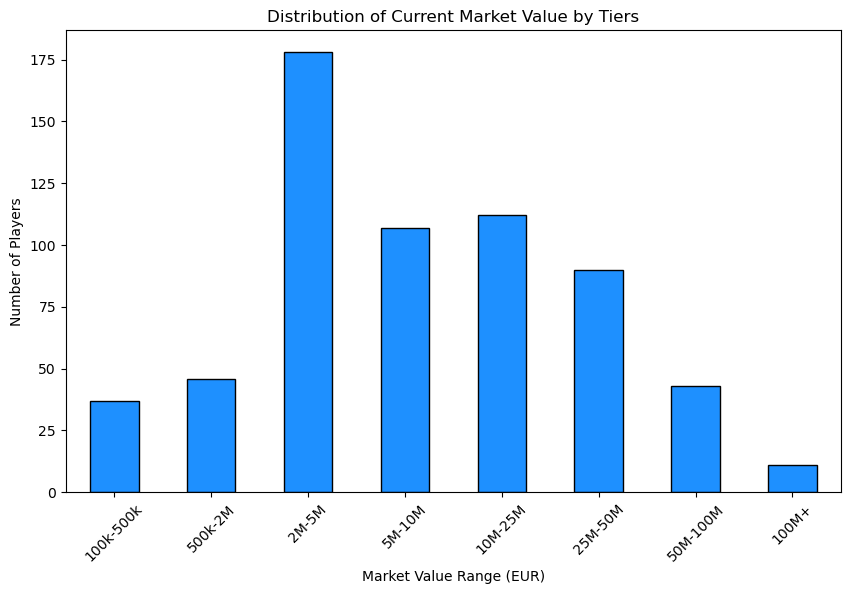

In [146]:
bins = [100000, 500000, 1000000, 5000000, 10000000, 25000000, 50000000, 100000000, np.inf]
labels = ['100k-500k', '500k-2M', '2M-5M', '5M-10M', '10M-25M', '25M-50M', '50M-100M', '100M+']

value_bins = pd.cut(y_train, bins=bins, labels=labels, right=False)

value_bins.value_counts()[labels].plot(
    kind='bar', 
    figsize=(10, 6), 
    color='dodgerblue', 
    edgecolor='black'
)

plt.title('Distribution of Current Market Value by Tiers')
plt.xlabel('Market Value Range (EUR)')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.show()

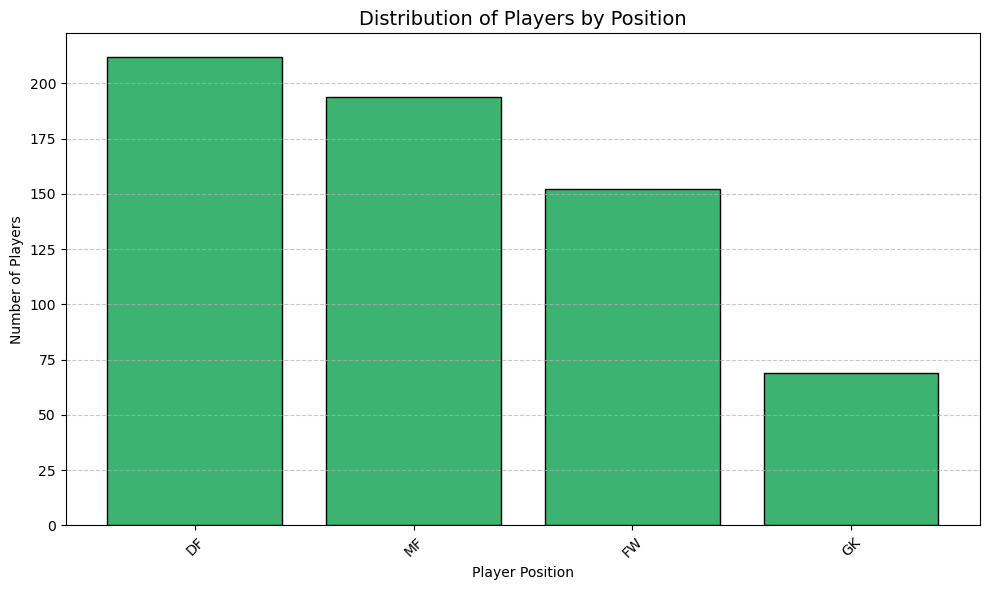

In [147]:
position_counts = X_train['Position'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(position_counts.index, position_counts.values, color='mediumseagreen', edgecolor='black')

plt.title('Distribution of Players by Position', fontsize=14)
plt.xlabel('Player Position')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

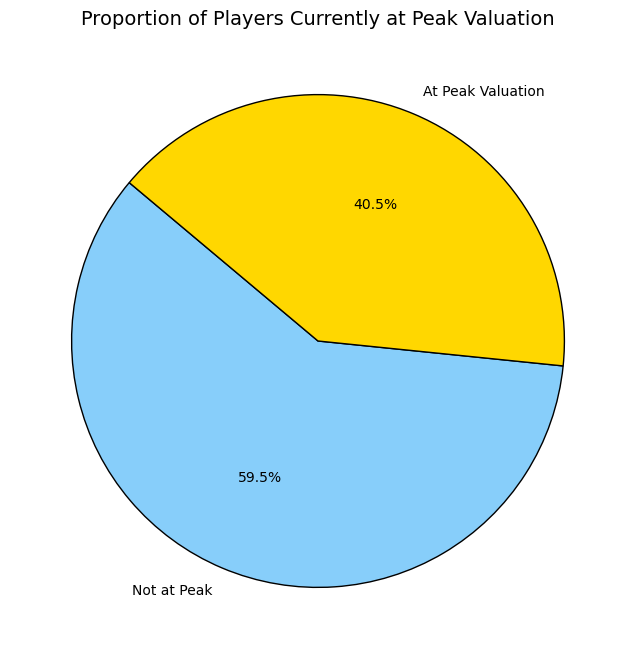

In [148]:
# === 2. PIE CHART: Players at their Peak Valuation ===

plt.figure(figsize=(8, 8))

# Get counts of True and False from the 'Apex MV' column
apex_counts = players_df['Apex MV'].value_counts()

# Map the True/False index to readable labels
labels = apex_counts.index.map({False: 'Not at Peak', True: 'At Peak Valuation'})

# Create the pie chart
plt.pie(apex_counts.values, labels=labels, autopct='%1.1f%%', 
        startangle=140, colors=['lightskyblue', 'gold'], 
        wedgeprops={'edgecolor': 'black'})

plt.title('Proportion of Players Currently at Peak Valuation', fontsize=14)
plt.show()

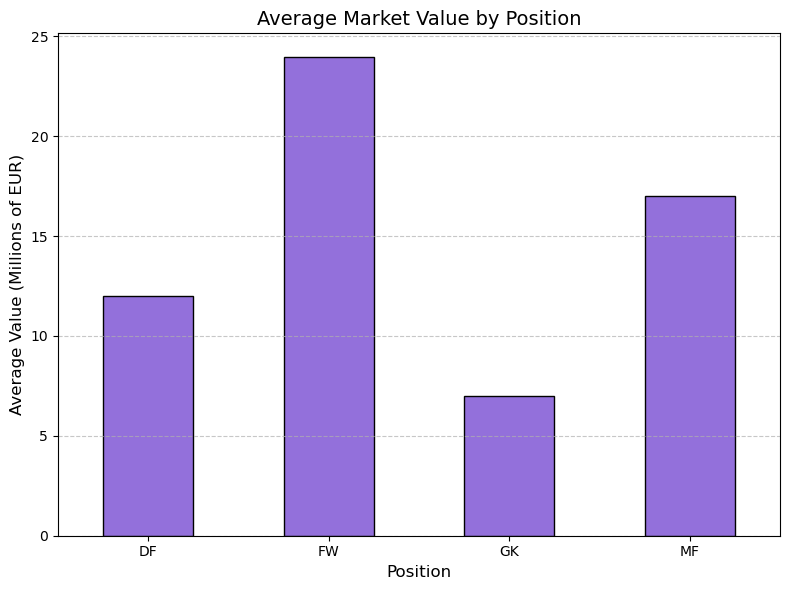

In [149]:
position_avg = players_df.groupby('Position', observed=False)['Current MV'].mean() / 1000000

# Plot directly using pandas
position_avg.plot(
    kind='bar', 
    figsize=(8, 6), 
    color='mediumpurple', 
    edgecolor='black'
)

plt.title('Average Market Value by Position', fontsize=14)
plt.xlabel('Position', fontsize=12)
plt.ylabel('Average Value (Millions of EUR)', fontsize=12)

# Keep the X-axis labels flat instead of rotated
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Used a cool imported library that helped the plot be more spaced out for the country names as they were overlapping really hard: [Adjusttext](https://adjusttext.readthedocs.io/en/latest/)

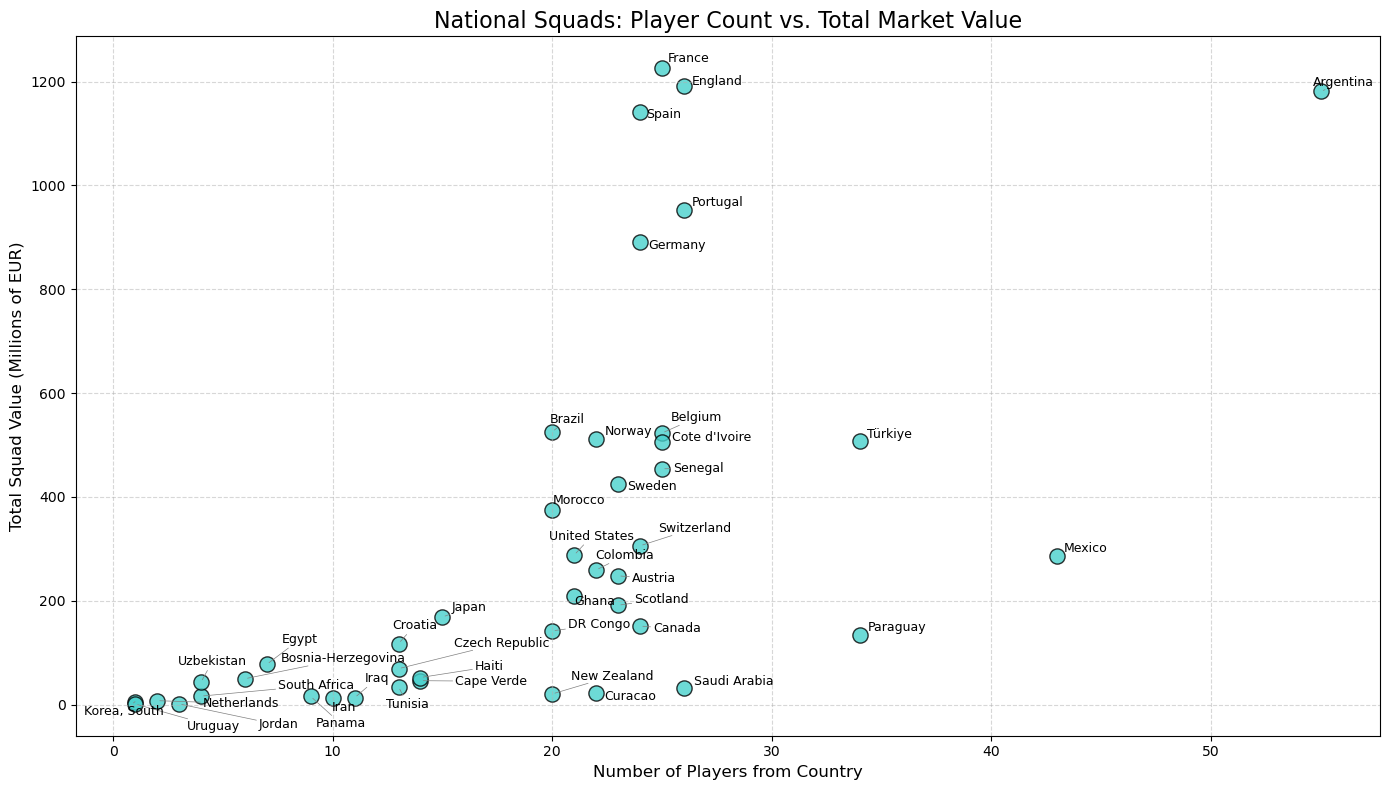

In [ ]:
plt.figure(figsize=(14, 8))

plt.scatter(
    country_scatter['player_count'], 
    country_scatter['total_value_m'], 
    color='mediumturquoise', 
    edgecolor='black', 
    s=120, 
    alpha=0.8
)

texts = []
for country, row in country_scatter.iterrows():
    texts.append(plt.text(row['player_count'], row['total_value_m'], country, fontsize=9))

# make country names more visible
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title('National Squads: Player Count vs. Total Market Value', fontsize=16)
plt.xlabel('Number of Players from Country', fontsize=12)
plt.ylabel('Total Squad Value (Millions of EUR)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()